# 04 — Non-RL Recommendation Module

**Goal:** Given the trained LightGBM predictor, recommend the next action by simulating each candidate action and choosing the one that maximises predicted `ProtocolValue(t+1)`.

**Approach (greedy policy):**
1. At each timestep, build 3 state variants — one per action (0=Lower, 1=Hold, 2=Raise)
2. Predict `ProtocolValue(t+1)` for each
3. Recommend the action with the highest predicted value
4. Evaluate: does the recommended action actually lead to improvement?

In [1]:
import sys, json, warnings, pickle
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR   = Path('../outputs')
FIGURES_DIR   = Path('../outputs/figures')

meta         = json.loads((PROCESSED_DIR/'feature_meta.json').read_text())
TARGET       = meta['target']
TARGET_NEXT  = meta['target_next']
FEATURE_COLS = meta['feature_cols']
ACTION_MAP   = meta['action_map']
SS_COL       = 'subsession'

with open(OUTPUTS_DIR/'lgbm_predictor.pkl','rb') as f:
    saved = pickle.load(f)
model = saved['model']

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.labelcolor':'#e6edf3','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#e6edf3',
    'grid.color':'#21262d','grid.linestyle':'--','font.family':'monospace'
})
print('Setup complete.')

Setup complete.


## 1. Load Features

In [2]:
df = pd.read_parquet(PROCESSED_DIR/'features.parquet')
df_game = df[df[SS_COL]>0].copy()
df_game = df_game.dropna(subset=FEATURE_COLS)
print(f'Game rows: {len(df_game):,}')

Game rows: 2,667


## 2. Greedy Policy — Action Recommendation

In [3]:
# For each timestep, vary the 'action' feature and pick the best
# action_col index in feature vector
action_feat = 'action'

if action_feat not in FEATURE_COLS:
    print(f'Note: "{action_feat}" not in feature cols — recommendation uses current state only.')
    # Fallback: just predict with current state, recommend Hold always
    X = df_game[FEATURE_COLS].values
    df_game['pred_next'] = model.predict(X)
    df_game['recommended_action'] = 1  # Hold
else:
    action_idx = FEATURE_COLS.index(action_feat)
    X_base = df_game[FEATURE_COLS].values.copy()
    preds_by_action = {}
    for a in [0, 1, 2]:
        X_mod = X_base.copy()
        X_mod[:, action_idx] = a
        preds_by_action[a] = model.predict(X_mod)

    pred_matrix = np.stack([preds_by_action[0], preds_by_action[1], preds_by_action[2]], axis=1)
    df_game['recommended_action'] = pred_matrix.argmax(axis=1)
    df_game['pred_next_best']     = pred_matrix.max(axis=1)
    df_game['pred_next_hold']     = preds_by_action[1]

print('Recommended action distribution:')
vc = df_game['recommended_action'].value_counts().sort_index()
for a, n in vc.items():
    print(f'  Action {a} ({ACTION_MAP[str(a)]}): {n} ({n/len(df_game):.1%})')

Note: "action" not in feature cols — recommendation uses current state only.
Recommended action distribution:
  Action 1 (Hold threshold): 2667 (100.0%)


## 3. Policy Evaluation

In [4]:
# Did the recommended action lead to improvement?
df_game['actual_next'] = df_game.groupby(SS_COL)[TARGET].shift(-1)
df_game['actual_delta'] = df_game['actual_next'] - df_game[TARGET]

df_eval = df_game.dropna(subset=['actual_next'])

# Improvement rate: fraction of steps where actual delta > 0
# Split by recommended action
print('Improvement rate by recommended action:')
for a in [0, 1, 2]:
    subset = df_eval[df_eval['recommended_action']==a]
    if len(subset) == 0: continue
    rate = (subset['actual_delta'] > 0).mean()
    mean_delta = subset['actual_delta'].mean()
    print(f'  Action {a} ({ACTION_MAP[str(a)]:20s}): {rate:.1%} positive steps, mean Δ={mean_delta:+.4f}')

overall_rate = (df_eval['actual_delta'] > 0).mean()
print(f'\nOverall improvement rate: {overall_rate:.1%}')

Improvement rate by recommended action:
  Action 1 (Hold threshold      ): 47.6% positive steps, mean Δ=-0.0008

Overall improvement rate: 47.6%


## 4. Visualise Recommendations Over Time

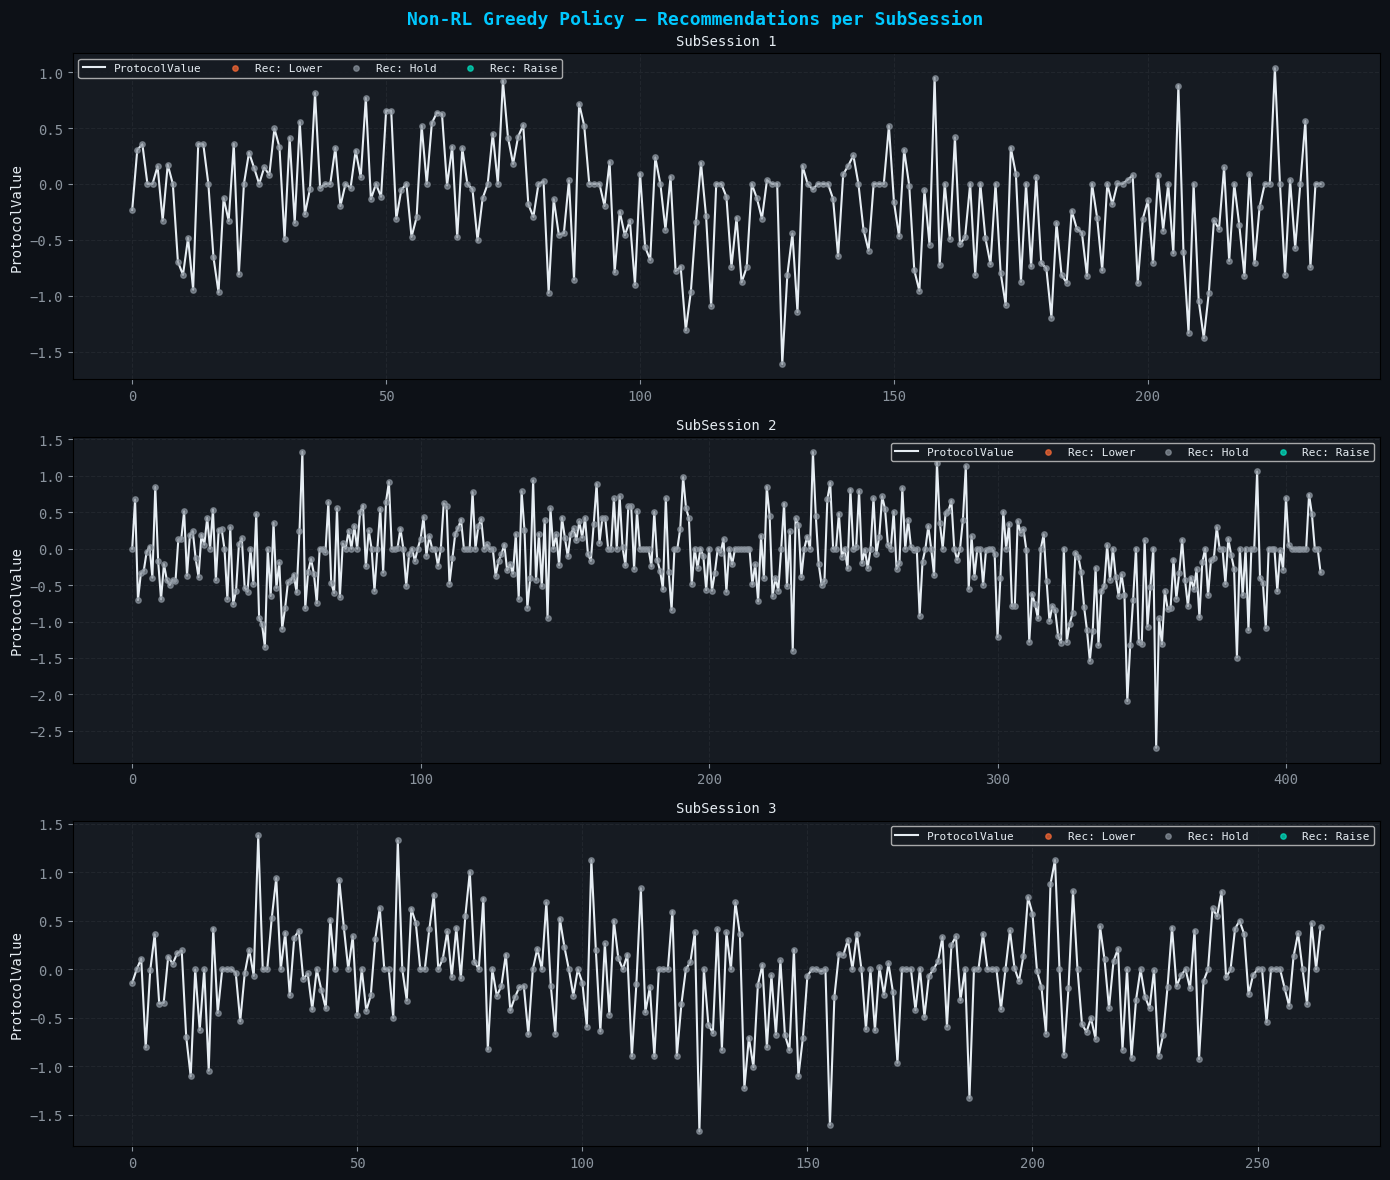

In [5]:
# Plot ProtocolValue + recommended actions for a few subsessions
n_plot = min(3, df_game[SS_COL].nunique())
plot_ss = sorted(df_game[SS_COL].unique())[:n_plot]

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 4*n_plot))
if n_plot == 1: axes = [axes]
fig.suptitle('Non-RL Greedy Policy — Recommendations per SubSession',
             color='#00c8ff', fontsize=13, fontweight='bold')

colors = {0:'#ff6b35', 1:'#8b949e', 2:'#00e5c3'}
labels = {0:'Lower', 1:'Hold', 2:'Raise'}

for ax, ss_id in zip(axes, plot_ss):
    ss_df = df_game[df_game[SS_COL]==ss_id].reset_index(drop=True)
    ax.plot(ss_df[TARGET], color='#e6edf3', lw=1.5, label='ProtocolValue', zorder=3)
    for a in [0, 1, 2]:
        idx = ss_df[ss_df['recommended_action']==a].index
        ax.scatter(idx, ss_df.loc[idx, TARGET], color=colors[a], s=15,
                   label=f'Rec: {labels[a]}', zorder=4, alpha=0.7)
    ax.set_title(f'SubSession {ss_id}', fontsize=10)
    ax.set_ylabel('ProtocolValue')
    ax.legend(fontsize=8, ncol=4)
    ax.grid(True)
    ax.set_facecolor('#161b22')

plt.tight_layout()
plt.savefig('../outputs/figures/nonrl_recommendations.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [6]:
# Save recommendation results
df_game.to_parquet(PROCESSED_DIR/'recommendations_nonrl.parquet', index=False)
print('Saved recommendations_nonrl.parquet')

Saved recommendations_nonrl.parquet
